<div style="
    background:linear-gradient(135deg,#4F46E5,#635BEE);
    border-radius:16px;
    padding:24px 28px;
    margin:10px 0 24px 0;
    color:white;
    box-shadow:0 6px 18px rgba(79,70,229,0.18);
">

<h1 style="
    margin:0;
    font-size:36px;
    font-weight:600;
    color:white;
">
Day 3 — Dimensionality Reduction with PCA
</h1>

<p style="
    margin:12px 0 0 0;
    font-size:17px;
    font-weight:500;
    color:#EEF2FF;
">
Reducing 561 smartphone sensor features while preserving as much information as possible
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:20px 24px;
    margin:14px 0 22px 0;
    color:#1F2937;
    line-height:1.8;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
Introduction
</h2>

<p>
The Human Activity Recognition dataset contains <b>561 smartphone sensor features</b> describing six daily activities.
</p>

<p>
Working with this many features makes the data difficult to visualize and may introduce overlapping or redundant information.
</p>

<p style="margin-bottom:0;">
Today, I will use <b style="color:#4F46E5;">Principal Component Analysis (PCA)</b> to reduce these dimensions while preserving as much of the dataset's information as possible.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:18px 24px;
    margin:14px 0 22px 0;
    color:#1F2937;
    line-height:1.75;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 14px 0;
    font-weight:500;
">
Today's Topics
</h2>

<div style="font-size:16px;">
<b style="color:#4F46E5;">01</b> — The Curse of Dimensionality<br>
<b style="color:#4F46E5;">02</b> — Understanding Principal Components<br>
<b style="color:#4F46E5;">03</b> — Why PCA Requires Scaling<br>
<b style="color:#4F46E5;">04</b> — Explained Variance Ratio<br>
<b style="color:#4F46E5;">05</b> — Cumulative Explained Variance<br>
<b style="color:#4F46E5;">06</b> — Choosing Components for 95% Variance<br>
<b style="color:#4F46E5;">07</b> — Two-Dimensional PCA Projection<br>
<b style="color:#4F46E5;">08</b> — Benefits and Trade-Offs of PCA
</div>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:18px 24px;
    margin:14px 0 22px 0;
    color:#1F2937;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
Hands-On Tasks
</h2>

<table style="
    width:100%;
    border-collapse:collapse;
    font-size:15px;
">

<tr style="background:#EEF2FF;">
    <th style="padding:12px;text-align:left;border-bottom:2px solid #C7D2FE;">Step</th>
    <th style="padding:12px;text-align:left;border-bottom:2px solid #C7D2FE;">Task</th>
    <th style="padding:12px;text-align:left;border-bottom:2px solid #C7D2FE;">Goal</th>
</tr>

<tr>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;color:#4F46E5;font-weight:bold;">01</td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;"><b>Prepare the Data</b></td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;">Combine the dataset files and select the sensor features.</td>
</tr>

<tr>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;color:#4F46E5;font-weight:bold;">02</td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;"><b>Scale the Features</b></td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;">Place the features on a comparable scale before PCA.</td>
</tr>

<tr>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;color:#4F46E5;font-weight:bold;">03</td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;"><b>Analyze Explained Variance</b></td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;">Measure how much information the components retain.</td>
</tr>

<tr>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;color:#4F46E5;font-weight:bold;">04</td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;"><b>Select the 95% Threshold</b></td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;">Choose the minimum number of components that preserves about 95% of the variance.</td>
</tr>

<tr>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;color:#4F46E5;font-weight:bold;">05</td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;"><b>Create a 2D Projection</b></td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;">Visualize the six activity groups using two components.</td>
</tr>

<tr>
    <td style="padding:12px;color:#4F46E5;font-weight:bold;">06</td>
    <td style="padding:12px;"><b>Evaluate the Trade-Off</b></td>
    <td style="padding:12px;">Explain what PCA preserved and what was lost.</td>
</tr>

</table>

</div>

<div style="
    background:linear-gradient(135deg,#EEF2FF,#F5F3FF);
    border:1px solid #C7D2FE;
    border-radius:14px;
    padding:20px 24px;
    margin:14px 0 22px 0;
">

<p style="
    color:#4F46E5;
    font-weight:bold;
    font-size:17px;
    margin:0 0 10px 0;
">
Today's Question
</p>

<p style="
    color:#1F2937;
    font-size:18px;
    line-height:1.6;
    margin:0;
">
Can PCA reduce the <b>561 smartphone sensor features</b> into a much smaller number of components while still preserving about <b>95% of the variance</b>?
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:18px 24px;
    margin:14px 0 24px 0;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
Day 3 Roadmap
</h2>

<div style="
    color:#1F2937;
    font-size:16px;
    line-height:2;
    text-align:center;
">
High-Dimensional Data
<span style="color:#4F46E5;font-weight:bold;"> → </span>
Scaling
<span style="color:#4F46E5;font-weight:bold;"> → </span>
PCA
<span style="color:#4F46E5;font-weight:bold;"> → </span>
Explained Variance
<span style="color:#4F46E5;font-weight:bold;"> → </span>
95% Threshold
<span style="color:#4F46E5;font-weight:bold;"> → </span>
2D Projection
<span style="color:#4F46E5;font-weight:bold;"> → </span>
Final Takeaway
</div>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-radius:14px;
    padding:20px;
    margin:18px 0 24px 0;
    text-align:center;
">

<h3 style="color:#4F46E5; margin-top:0;">
PCA in One Picture
</h3>

<img src="https://miro.medium.com/1%2Ao7J9PvfXEgAH1_6TKAgehQ.png" width="700" style="max-width:100%; border-radius:10px;">

<p style="color:#374151; line-height:1.7; margin:14px 0 5px 0;">
PCA finds the directions that preserve the most variance, then projects the data onto fewer dimensions.
</p>

<p style="color:#6B7280; font-size:12px; margin:0;">
Source: Medium — Mastering PCA for Dimensionality Reduction
</p>

</div>

In this illustration, PCA reduces three dimensions to two. In my dataset, I used the same idea to reduce 561 sensor features to 104 components while preserving 95.05% of the variance.

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:20px 24px;
    margin:18px 0 22px 0;
    color:#1F2937;
    line-height:1.8;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
1. Why High Dimensionality Is a Problem
</h2>

<p>
The Human Activity Recognition dataset describes every record using <b>561 sensor features</b>.
</p>

<p style="margin-bottom:0;">
As the number of features increases, the data becomes harder to explore, distances become less meaningful, and models may learn unnecessary or repeated patterns. This problem is known as the <b style="color:#4F46E5;">curse of dimensionality</b>.
</p>

</div>

<div style="
    display:grid;
    grid-template-columns:repeat(2,1fr);
    gap:14px;
    margin:14px 0 22px 0;
">

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-radius:12px;
    padding:16px 18px;
">
<p style="color:#4F46E5;font-weight:bold;margin:0 0 8px 0;">
Data Becomes Sparse
</p>
<p style="color:#4B5563;margin:0;line-height:1.6;">
With more dimensions, observations become more spread out and harder to compare.
</p>
</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-radius:12px;
    padding:16px 18px;
">
<p style="color:#4F46E5;font-weight:bold;margin:0 0 8px 0;">
Distances Lose Meaning
</p>
<p style="color:#4B5563;margin:0;line-height:1.6;">
It becomes harder to decide which observations are truly close or similar.
</p>
</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-radius:12px;
    padding:16px 18px;
">
<p style="color:#4F46E5;font-weight:bold;margin:0 0 8px 0;">
Overfitting Risk Increases
</p>
<p style="color:#4B5563;margin:0;line-height:1.6;">
A model may learn noise or repeated patterns instead of useful structure.
</p>
</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-radius:12px;
    padding:16px 18px;
">
<p style="color:#4F46E5;font-weight:bold;margin:0 0 8px 0;">
Visualization Becomes Impossible
</p>
<p style="color:#4B5563;margin:0;line-height:1.6;">
Humans can visualize two or three dimensions, but not 561 features at once.
</p>
</div>

</div>

<div style="
    background:#EEF2FF;
    border:1px solid #C7D2FE;
    border-left:6px solid #4F46E5;
    border-radius:12px;
    padding:16px 20px;
    margin:14px 0 26px 0;
">

<p style="
    color:#3730A3;
    font-weight:bold;
    margin:0 0 8px 0;
">
The Challenge
</p>

<p style="
    color:#1F2937;
    margin:0;
    line-height:1.7;
">
How can I make the dataset smaller and easier to visualize without discarding most of the useful information stored in its 561 features?
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:20px 24px;
    margin:18px 0 22px 0;
    color:#1F2937;
    line-height:1.8;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
2. What Does PCA Do?
</h2>

<p>
<b>Principal Component Analysis (PCA)</b> transforms the original features into new variables called <b>principal components</b>.
</p>

<p>
The first component captures the largest possible amount of variance. The second component captures the next largest amount while pointing in a different direction.
</p>

<p style="margin-bottom:0;">
By keeping only the most informative components, PCA can reduce the dataset's dimensions while retaining much of its original information.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#EEF2FF,#F5F3FF);
    border:1px solid #C7D2FE;
    border-radius:14px;
    padding:22px 24px;
    margin:14px 0 24px 0;
    text-align:center;
">

<div style="
    color:#1F2937;
    font-size:17px;
    line-height:2;
">

<span style="
    background:white;
    border:1px solid #DDE1EA;
    border-radius:10px;
    padding:10px 16px;
    font-weight:bold;
">
561 Original Features
</span>

<span style="
    color:#4F46E5;
    font-size:24px;
    font-weight:bold;
    padding:0 12px;
">
→
</span>

<span style="
    background:#4F46E5;
    color:white;
    border-radius:10px;
    padding:10px 18px;
    font-weight:bold;
">
PCA
</span>

<span style="
    color:#4F46E5;
    font-size:24px;
    font-weight:bold;
    padding:0 12px;
">
→
</span>

<span style="
    background:white;
    border:1px solid #DDE1EA;
    border-radius:10px;
    padding:10px 16px;
    font-weight:bold;
">
Fewer Components
</span>

</div>

<p style="
    color:#4B5563;
    margin:20px 0 0 0;
    line-height:1.6;
">
The goal is to remove unnecessary dimensions while keeping the directions that contain the most variance.
</p>

</div>

<div style="
    background:#FFFDF5;
    border:1px solid #F4D99B;
    border-left:6px solid #E0A72B;
    border-radius:12px;
    padding:16px 20px;
    margin:14px 0 24px 0;
">

<p style="
    color:#9A6700;
    font-weight:bold;
    margin:0 0 8px 0;
">
Important Trade-Off
</p>

<p style="
    color:#374151;
    margin:0;
    line-height:1.7;
">
The principal components are combinations of the original sensor features. This makes the dataset smaller, but the new components are harder to interpret than the original columns.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:20px 24px;
    margin:18px 0 22px 0;
    color:#1F2937;
    line-height:1.8;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
3. Understanding Explained Variance
</h2>

<p>
PCA arranges the principal components according to how much variance each one captures from the original data.
</p>

<p>
The <b>explained variance ratio</b> shows the proportion of information captured by each component.
</p>

<p style="margin-bottom:0;">
By adding these ratios together, I can measure how much of the dataset's total variance is preserved as more components are included.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#EEF2FF,#F5F3FF);
    border:1px solid #C7D2FE;
    border-radius:14px;
    padding:20px 24px;
    margin:14px 0 22px 0;
">

<p style="
    color:#4F46E5;
    font-weight:bold;
    font-size:17px;
    margin:0 0 14px 0;
">
Simple Example
</p>

<div style="
    display:grid;
    grid-template-columns:repeat(3,1fr);
    gap:14px;
    text-align:center;
">

<div style="background:white;border-radius:10px;padding:14px;">
    <b style="color:#4F46E5;font-size:20px;">PC1</b><br>
    <span style="color:#4B5563;">50% of variance</span>
</div>

<div style="background:white;border-radius:10px;padding:14px;">
    <b style="color:#4F46E5;font-size:20px;">PC2</b><br>
    <span style="color:#4B5563;">25% of variance</span>
</div>

<div style="background:white;border-radius:10px;padding:14px;">
    <b style="color:#4F46E5;font-size:20px;">Total</b><br>
    <span style="color:#4B5563;">75% retained</span>
</div>

</div>

<p style="
    color:#374151;
    margin:18px 0 0 0;
    text-align:center;
    line-height:1.6;
">
Keeping PC1 and PC2 would preserve 75% of the dataset's total variance in this example.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:12px;
    padding:16px 20px;
    margin:14px 0 24px 0;
">

<p style="
    color:#4F46E5;
    font-weight:bold;
    margin:0 0 8px 0;
">
Why Use a 95% Threshold?
</p>

<p style="
    color:#1F2937;
    margin:0;
    line-height:1.7;
">
Keeping about <b>95% of the variance</b> provides a practical balance: the dataset becomes smaller while most of its original information is retained.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:20px 24px;
    margin:18px 0 22px 0;
    color:#1F2937;
    line-height:1.8;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
4. Why PCA Requires Scaling
</h2>

<p>
PCA identifies important directions by measuring variance. Therefore, features with larger numerical ranges can appear more important even when their large values are caused only by their measurement scale.
</p>

<p style="margin-bottom:0;">
I will apply <b style="color:#4F46E5;">StandardScaler</b> before PCA so that every sensor feature contributes on a comparable scale.
</p>

</div>

<div style="
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:16px;
    margin:14px 0 24px 0;
">

<div style="
    background:#FFF7F7;
    border:1px solid #F3CACA;
    border-radius:12px;
    padding:18px 20px;
">

<p style="
    color:#C2415D;
    font-weight:bold;
    margin:0 0 10px 0;
">
Without Scaling
</p>

<p style="
    color:#374151;
    margin:0;
    line-height:1.7;
">
Features with larger ranges may dominate the principal components and create a misleading result.
</p>

</div>

<div style="
    background:#F0FDF8;
    border:1px solid #BDE8D8;
    border-radius:12px;
    padding:18px 20px;
">

<p style="
    color:#16856A;
    font-weight:bold;
    margin:0 0 10px 0;
">
After Scaling
</p>

<p style="
    color:#374151;
    margin:0;
    line-height:1.7;
">
The features are centered around zero and placed on a comparable scale before PCA.
</p>

</div>

</div>

<div style="
    background:#FFFDF5;
    border:1px solid #F4D99B;
    border-left:6px solid #E0A72B;
    border-radius:12px;
    padding:16px 20px;
    margin:14px 0 26px 0;
">

<p style="
    color:#9A6700;
    font-weight:bold;
    margin:0 0 8px 0;
">
Important
</p>

<p style="
    color:#374151;
    margin:0;
    line-height:1.7;
">
Scaling changes the numerical representation of the features, but it does not remove records, change the activity labels, or reduce the number of dimensions. The dimensionality reduction happens later when PCA is applied.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:20px 24px;
    margin:18px 0 24px 0;
    color:#1F2937;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
5. When Should PCA Be Used?
</h2>

<table style="
    width:100%;
    border-collapse:collapse;
    font-size:15px;
">

<tr style="background:#EEF2FF;">
    <th style="padding:12px;text-align:left;border-bottom:2px solid #C7D2FE;">
        PCA Is Useful When
    </th>
    <th style="padding:12px;text-align:left;border-bottom:2px solid #C7D2FE;">
        PCA May Not Be Suitable When
    </th>
</tr>

<tr>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;">
        The dataset contains many numerical features.
    </td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;">
        Direct feature interpretation is essential.
    </td>
</tr>

<tr>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;">
        Several features contain overlapping information.
    </td>
    <td style="padding:12px;border-bottom:1px solid #E5E7EB;">
        Important patterns are strongly non-linear.
    </td>
</tr>

<tr>
    <td style="padding:12px;">
        The data needs to be visualized in two or three dimensions.
    </td>
    <td style="padding:12px;">
        The original feature names must remain unchanged.
    </td>
</tr>

</table>

</div>

<div style="
    background:linear-gradient(135deg,#4F46E5,#635BEE);
    border-radius:14px;
    padding:20px 24px;
    margin:20px 0 24px 0;
    color:white;
">

<h2 style="
    color:white;
    margin:0;
    font-weight:500;
">
Hands-On Practice
</h2>

<p style="
    color:#EEF2FF;
    margin:10px 0 0 0;
    line-height:1.6;
">
Applying PCA to the Human Activity Recognition dataset step by step
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:5px solid #4F46E5;
    border-radius:10px;
    padding:14px 18px;
    margin:12px 0 16px 0;
">

<p style="
    color:#3730A3;
    margin:0;
    line-height:1.7;
">
<b>Note:</b> I will import the libraries needed for loading the dataset, numerical calculations, feature scaling, PCA, and visualization.
</p>

</div>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:20px 24px;
    margin:18px 0 22px 0;
    color:#1F2937;
    line-height:1.8;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
6. Load and Combine the Dataset
</h2>

<p>
The Kaggle dataset is provided in two files: one for training records and one for testing records.
</p>

<p style="margin-bottom:0;">
Because this notebook focuses on understanding and reducing the dataset's dimensions rather than training a classifier, I will combine both files into one complete dataset before applying PCA.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:5px solid #4F46E5;
    border-radius:10px;
    padding:14px 18px;
    margin:12px 0 16px 0;
">

<p style="
    color:#3730A3;
    margin:0;
    line-height:1.7;
">
<b>Note:</b> First, I will load the training and testing files separately so I can inspect their sizes before combining them.
</p>

</div>

In [31]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (7352, 563)
Testing data shape: (2947, 563)


<div style="
    background:#EEF2FF;
    border-left:5px solid #4F46E5;
    border-radius:10px;
    padding:14px 18px;
    margin:12px 0 16px 0;
">

<p style="
    color:#3730A3;
    margin:0;
    line-height:1.7;
">
<b>Note:</b> I will display the first few training records to understand how the sensor features, subject identifier, and activity label are stored.
</p>

</div>

In [32]:
train_df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


<div style="
    background:#EEF2FF;
    border-left:5px solid #4F46E5;
    border-radius:10px;
    padding:14px 18px;
    margin:12px 0 16px 0;
">

<p style="
    color:#3730A3;
    margin:0;
    line-height:1.7;
">
<b>Note:</b> Now I will combine both files into one DataFrame and reset the row index so the complete dataset can be analyzed together.
</p>

</div>

In [33]:
df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (10299, 563)


<div style="
    background:#F8FAFC;
    border:1px solid #DDE1EA;
    border-left:6px solid #4F46E5;
    border-radius:14px;
    padding:20px 24px;
    margin:18px 0 22px 0;
    color:#1F2937;
    line-height:1.8;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 16px 0;
    font-weight:500;
">
7. Understand the Dataset Columns
</h2>

<p style="margin-bottom:0;">
Before applying PCA, I need to separate the 561 sensor features from the activity label and subject identifier.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-left:5px solid #4F46E5;
    border-radius:10px;
    padding:14px 18px;
    margin:12px 0 16px 0;
">

<p style="
    color:#3730A3;
    margin:0;
    line-height:1.7;
">
<b>Note:</b> Since the dataset contains hundreds of columns, I will display only the last few column names to confirm where the subject identifier and activity label are stored.
</p>

</div>

In [34]:
df.columns[-10:].tolist()

['fBodyBodyGyroJerkMag-kurtosis()',
 'angle(tBodyAccMean,gravity)',
 'angle(tBodyAccJerkMean),gravityMean)',
 'angle(tBodyGyroMean,gravityMean)',
 'angle(tBodyGyroJerkMean,gravityMean)',
 'angle(X,gravityMean)',
 'angle(Y,gravityMean)',
 'angle(Z,gravityMean)',
 'subject',
 'Activity']

<div style="background:#ECFDF5; border-left:5px solid #10B981; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#047857;">Observation</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
The last two columns are <code>subject</code> and <code>Activity</code>.  
The remaining 561 columns represent numerical measurements extracted from the smartphone sensors.
</p>

</div>

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-left:6px solid #4F46E5; border-radius:14px; padding:22px; margin:18px 0;">

<h2 style="color:#4F46E5; margin-top:0;">Separate Features and Activity Labels</h2>

<p style="color:#1F2937; line-height:1.7; margin-bottom:0;">
PCA should be applied only to the numerical sensor measurements.  
Therefore, I will separate the 561 features from the activity labels and subject identifiers.
</p>

</div>

<div style="background:#EEF2FF; border-left:5px solid #4F46E5; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#4338CA;">Why exclude these columns?</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
<code>Activity</code> is a categorical label, while <code>subject</code> is only an identifier.  
Including either one in PCA could create misleading principal components.
</p>

</div>

In [35]:
# Separate the numerical features from the descriptive columns
X = df.drop(columns=["subject", "Activity"])
y = df["Activity"]
subjects = df["subject"]

print("Feature matrix shape:", X.shape)
print("Activity labels shape:", y.shape)
print("Number of activities:", y.nunique())

Feature matrix shape: (10299, 561)
Activity labels shape: (10299,)
Number of activities: 6


<div style="background:#ECFDF5; border-left:5px solid #10B981; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#047857;">Observation</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
The feature matrix contains <b>10,299 observations</b> and <b>561 numerical features</b>.  
The activity labels contain six different activity classes.  
The <code>subject</code> and <code>Activity</code> columns were successfully excluded from the PCA input.
</p>

</div>

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-left:6px solid #4F46E5; border-radius:14px; padding:22px; margin:18px 0;">

<h2 style="color:#4F46E5; margin-top:0;">Data Quality Check</h2>

<p style="color:#1F2937; line-height:1.7; margin-bottom:0;">
Before scaling and applying PCA, I will check whether the feature matrix contains missing values.
</p>

</div>

<div style="background:#EEF2FF; border-left:5px solid #4F46E5; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#4338CA;">Why check missing values?</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
StandardScaler and PCA require complete numerical data.  
Missing values must be handled before these methods can be applied.
</p>

</div>

In [36]:
# Check for missing values in the feature matrix
missing_values = X.isnull().sum().sum()

print("Total missing values:", missing_values)

Total missing values: 0


<div style="background:#ECFDF5; border-left:5px solid #10B981; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#047857;">Observation</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
The feature matrix contains <b>0 missing values</b>.  
Therefore, no rows need to be removed and no values need to be imputed before applying PCA.
</p>

</div>

<div style="background:linear-gradient(135deg,#4F46E5,#635BEE); border-radius:16px; padding:24px 28px; margin:24px 0; color:white;">

<h2 style="margin:0 0 8px 0; color:white;">Step 1 — Scale the Features</h2>

<p style="margin:0; opacity:0.95;">
Place all sensor measurements on a comparable scale before applying PCA.
</p>

</div>

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-left:6px solid #4F46E5; border-radius:14px; padding:22px; margin:18px 0;">

<h3 style="color:#4F46E5; margin-top:0;">Why is scaling necessary?</h3>

<p style="color:#1F2937; line-height:1.7;">
PCA identifies directions with the greatest variance. If some features have larger numerical ranges than others, they may dominate the principal components only because of their scale.
</p>

<p style="color:#1F2937; line-height:1.7; margin-bottom:0;">
<code>StandardScaler</code> transforms each feature so that it has approximately a mean of 0 and a standard deviation of 1.
</p>

</div>

In [37]:
# Create the scaler
scaler = StandardScaler()

# Learn the scaling values and transform the features
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print("Mean after scaling:", round(X_scaled.mean(), 4))
print("Standard deviation after scaling:", round(X_scaled.std(), 4))

Scaled data shape: (10299, 561)
Mean after scaling: 0.0
Standard deviation after scaling: 1.0


<div style="background:#ECFDF5; border-left:5px solid #10B981; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#047857;">Observation</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
The dataset still contains <b>10,299 observations</b> and <b>561 features</b>, confirming that scaling changed the values without reducing the dimensions.
The scaled data has a mean of <b>0.0</b> and a standard deviation of <b>1.0</b>, so the features are now comparable.
</p>

</div>

<div style="background:#EEF2FF; border-left:5px solid #4F46E5; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#4338CA;">Visual Scaling Check</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
To make the effect of StandardScaler visible, I will compare one sensor feature before and after scaling.
The distribution shape should remain similar, while its center and numerical scale should change.
</p>

</div>

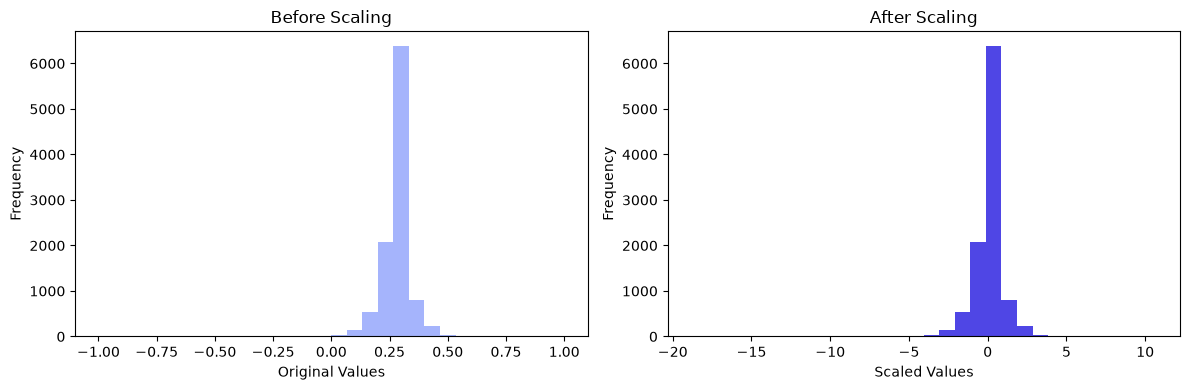

In [38]:
feature = X.columns[0]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(X[feature], bins=30, color="#A5B4FC")
plt.title("Before Scaling")
plt.xlabel("Original Values")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(X_scaled[:, 0], bins=30, color="#4F46E5")
plt.title("After Scaling")
plt.xlabel("Scaled Values")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

The two plots have the same general distribution shape, but the values in the second plot are centered around zero.

This shows that scaling changed the feature's scale without changing its underlying pattern.

<div style="background:linear-gradient(135deg,#4F46E5,#635BEE); border-radius:16px; padding:24px 28px; margin:24px 0; color:white;">

<h2 style="margin:0 0 8px 0; color:white;">Step 2 — Apply PCA</h2>

<p style="margin:0; opacity:0.95;">
Measure how much variance can be preserved using fewer dimensions.
</p>

</div>

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-left:6px solid #4F46E5; border-radius:14px; padding:22px; margin:18px 0;">

<h3 style="color:#4F46E5; margin-top:0;">Fit PCA Using All Components</h3>

<p style="color:#1F2937; line-height:1.7;">
First, PCA will examine all 561 features. This allows me to measure how much variance is captured by each principal component before deciding how many components to keep.
</p>

<p style="color:#1F2937; line-height:1.7; margin-bottom:0;">
At this stage, no final number of components is selected.
</p>

</div>

In [39]:
# Apply PCA without selecting the number of components yet
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Number of available components:", len(explained_variance))
print("Variance explained by PC1:", round(explained_variance[0], 4))
print("Variance explained by PC2:", round(explained_variance[1], 4))

Number of available components: 561
Variance explained by PC1: 0.5074
Variance explained by PC2: 0.0624


<div style="background:#ECFDF5; border-left:5px solid #10B981; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#047857;">Observation</b>

<p style="color:#374151; line-height:1.7; margin-bottom:0;">
PCA produced <b>561 possible components</b>, matching the original number of features.
The first component explains <b>50.74%</b> of the variance, while the second explains <b>6.24%</b>.
Together, the first two components preserve approximately <b>56.98%</b> of the dataset's variance.
</p>

</div>

<div style="background:linear-gradient(135deg,#4F46E5,#635BEE); border-radius:16px; padding:24px 28px; margin:24px 0; color:white;">

<h2 style="margin:0 0 8px 0; color:white;">Step 3 — Choose the Number of Components</h2>

<p style="margin:0; opacity:0.95;">
Find the smallest number of components that preserves at least 95% of the variance.
</p>

</div>

<div style="background:#EEF2FF; border-left:5px solid #4F46E5; border-radius:10px; padding:15px 18px; margin:14px 0;">

<b style="color:#4338CA;">Why 95%?</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
The 95% threshold provides a practical balance: it keeps most of the dataset's information while removing dimensions that contribute relatively little additional variance.
</p>

</div>

In [40]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components needed for 95% variance:", n_components_95)
print("Variance retained:", round(cumulative_variance[n_components_95 - 1], 4))

Components needed for 95% variance: 104
Variance retained: 0.9505


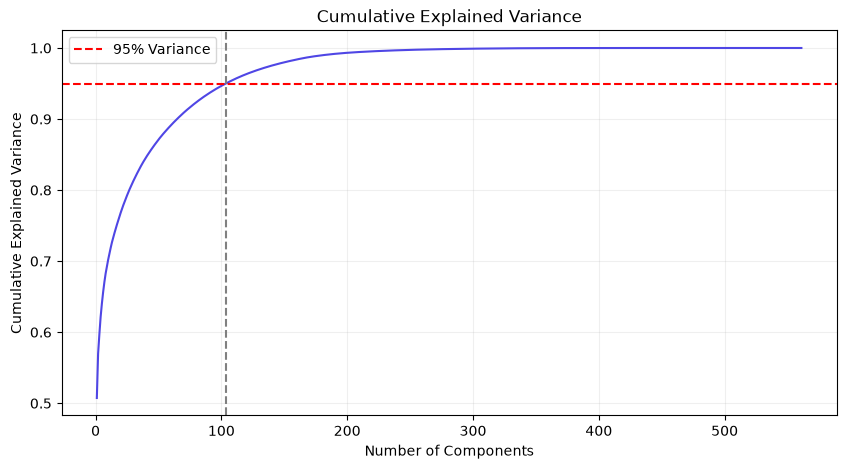

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    color="#4F46E5"
)

plt.axhline(0.95, color="red", linestyle="--", label="95% Variance")
plt.axvline(n_components_95, color="gray", linestyle="--")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-radius:14px; padding:22px; margin:18px 0;">

<h3 style="color:#4F46E5; margin-top:0;">How to Read This Plot</h3>

<div style="display:flex; gap:15px; flex-wrap:wrap;">

<div style="flex:1; min-width:190px; background:white; border-radius:10px; padding:15px; border-top:4px solid #4F46E5;">
<b style="color:#4F46E5;">1 — Follow the Curve</b>
<p style="color:#4B5563; margin-bottom:0;">
The blue curve shows how much information is collected as more components are added.
</p>
</div>

<div style="flex:1; min-width:190px; background:white; border-radius:10px; padding:15px; border-top:4px solid #EF4444;">
<b style="color:#EF4444;">2 — Find the Target</b>
<p style="color:#4B5563; margin-bottom:0;">
The red dashed line represents the goal of preserving 95% of the variance.
</p>
</div>

<div style="flex:1; min-width:190px; background:white; border-radius:10px; padding:15px; border-top:4px solid #6B7280;">
<b style="color:#4B5563;">3 — Read the Decision</b>
<p style="color:#4B5563; margin-bottom:0;">
The gray line marks the first number of components that reaches the 95% target.
</p>
</div>

</div>
</div>

<div style="background:linear-gradient(135deg,#4F46E5,#635BEE); color:white; border-radius:14px; padding:20px 24px; margin:18px 0;">

<div style="font-size:14px; opacity:0.85;"></div>

<h3 style="margin:7px 0; color:white;">
561 Original Features → 104 Principal Components
</h3>

<p style="margin:0; line-height:1.7;">
The selected components preserve at least 95% of the dataset's variance.
The curve becomes flatter afterward, meaning that the remaining components add only a small amount of new information.
</p>

</div>

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-left:6px solid #4F46E5; border-radius:14px; padding:22px; margin:18px 0;">

<h3 style="color:#4F46E5; margin-top:0;">What If I Choose a Different Target?</h3>

<p style="color:#1F2937; line-height:1.7; margin-bottom:0;">
Keeping more variance usually requires more components. I will compare several thresholds to understand why 95% is a reasonable choice.
</p>

</div>

In [42]:
variance_targets = [0.80, 0.90, 0.95, 0.99]
components_needed = []

for target in variance_targets:
    number = np.argmax(cumulative_variance >= target) + 1
    components_needed.append(number)

threshold_comparison = pd.DataFrame({
    "Variance Target": ["80%", "90%", "95%", "99%"],
    "Components Needed": components_needed
})

threshold_comparison

,Variance Target,Components Needed
0,80%,27
1,90%,65
2,95%,104
3,99%,182


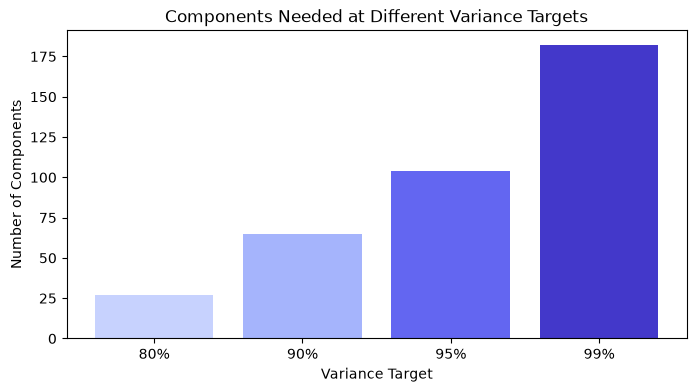

In [43]:
plt.figure(figsize=(8, 4))

plt.bar(
    threshold_comparison["Variance Target"],
    threshold_comparison["Components Needed"],
    color=["#C7D2FE", "#A5B4FC", "#6366F1", "#4338CA"]
)

plt.xlabel("Variance Target")
plt.ylabel("Number of Components")
plt.title("Components Needed at Different Variance Targets")
plt.show()

<div style="background:#EEF2FF; border-left:5px solid #4F46E5; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#4338CA;">The Trade-off</b>

<p style="color:#374151; line-height:1.7; margin-bottom:0;">
A lower target uses fewer components but loses more information.  
A higher target preserves more information, but the reduction becomes smaller.
The 95% target gives a balance between these two sides.
</p>

</div>

### Observation

The number of components increases as the variance target becomes higher.

Keeping 95% of the variance requires 104 components, while reaching 99% requires about 182 components. This is a large increase in dimensions for only 3.95% more variance.

For this dataset, 95% gives a better balance between preserving information and reducing the number of dimensions.

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-left:6px solid #4F46E5; border-radius:14px; padding:22px; margin:18px 0;">

<h3 style="color:#4F46E5; margin-top:0;">How Much Does Each Component Add?</h3>

<p style="color:#1F2937; line-height:1.7; margin-bottom:0;">
The cumulative plot showed the total variance collected over time. Now I will examine the contribution of the first 15 components separately.
</p>

</div>

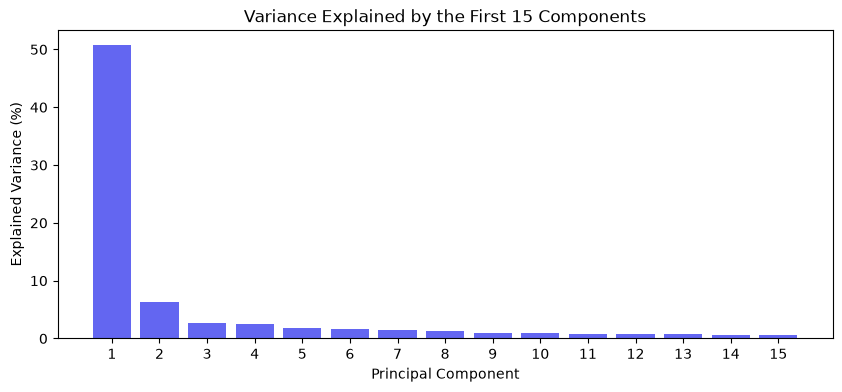

In [44]:
first_components = explained_variance[:15] * 100

plt.figure(figsize=(10, 4))

plt.bar(
    range(1, 16),
    first_components,
    color="#6366F1"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Variance Explained by the First 15 Components")
plt.xticks(range(1, 16))
plt.show()

### Observation

The first principal component explains about 50.74% of the total variance, making it much more informative than the other components.

The second component adds about 6.24%, while the contribution of each following component becomes gradually smaller.

This shows that a large part of the dataset's variation is concentrated in the first component, but several additional components are still needed to reach the 95% target.

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-left:6px solid #4F46E5; border-radius:14px; padding:22px; margin:18px 0;">

<h3 style="color:#4F46E5; margin-top:0;">Which Features Shape PC1?</h3>

<p style="color:#1F2937; line-height:1.7; margin-bottom:0;">
PC1 is a combination of the original sensor features. I will examine its largest loadings to see which measurements contribute most strongly to this component.
</p>

</div>

In [45]:
# Get the feature loadings for PC1
pc1_loadings = pd.Series(
    pca.components_[0],
    index=X.columns
)

# Select the 10 strongest loadings
top_pc1_features = pc1_loadings.abs().sort_values(
    ascending=False
).head(10)

top_pc1_features

fBodyAcc-sma()                0.058616
fBodyAccJerk-sma()            0.058578
fBodyGyro-sma()               0.058553
tBodyAccJerk-sma()            0.058549
tBodyAccJerkMag-mean()        0.058495
tBodyAccJerkMag-sma()         0.058495
fBodyBodyAccJerkMag-mean()    0.058108
fBodyBodyAccJerkMag-sma()     0.058108
tBodyAccJerkMag-mad()         0.058003
tBodyAccJerkMag-std()         0.057973
dtype: float64

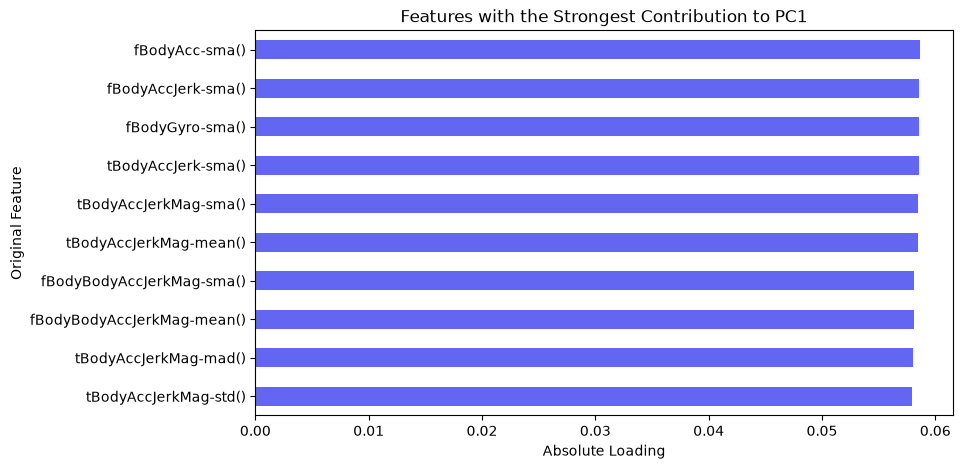

In [46]:
plt.figure(figsize=(9, 5))

top_pc1_features.sort_values().plot(
    kind="barh",
    color="#6366F1"
)

plt.xlabel("Absolute Loading")
plt.ylabel("Original Feature")
plt.title("Features with the Strongest Contribution to PC1")
plt.show()

### Observation

The strongest PC1 loadings are almost equal, with values close to 0.058.

Most of these features measure acceleration, jerk, or gyroscope movement in either the time or frequency domain. This suggests that PC1 combines several related movement measurements rather than depending on one feature.

This may explain why PC1 helped separate static activities from moving activities in the 2D PCA plot.

<div style="background:linear-gradient(135deg,#4F46E5,#635BEE); border-radius:16px; padding:24px 28px; margin:24px 0; color:white;">

<h2 style="margin:0 0 8px 0; color:white;">Step 4 — Reduce the Dataset</h2>

<p style="margin:0; opacity:0.95;">
Transform the original 561 features into a smaller set of principal components.
</p>

</div>

<div style="background:#EEF2FF; border-left:5px solid #4F46E5; border-radius:10px; padding:15px 18px; margin:14px 0;">

<b style="color:#4338CA;">What happens here?</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
Now that I know how many components are needed, I can apply PCA again using that number.
The dataset will have fewer columns, while still keeping about 95% of its variance.
</p>

</div>

In [47]:
# Apply PCA using the selected number of components
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)

print("Shape before PCA:", X_scaled.shape)
print("Shape after PCA:", X_pca_95.shape)
print("Variance retained:", round(pca_95.explained_variance_ratio_.sum(), 4))

Shape before PCA: (10299, 561)
Shape after PCA: (10299, 104)
Variance retained: 0.9505


<div style="background:#ECFDF5; border-left:5px solid #10B981; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#047857;">Observation</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
PCA reduced the dataset from <b>561 features</b> to <b>104 components</b>, while keeping <b>95.05%</b> of the total variance.
The number of observations remained unchanged at <b>10,299</b>.
</p>

</div>

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-left:6px solid #4F46E5; border-radius:14px; padding:22px; margin:18px 0;">

<h3 style="color:#4F46E5; margin-top:0;">Create the Reduced Dataset</h3>

<p style="color:#1F2937; line-height:1.7; margin-bottom:0;">
The PCA result is currently stored as a NumPy array. I will convert it into a DataFrame with clear component names, then add the activity and subject columns back for future analysis.
</p>

</div>

In [48]:
# Create names for the principal components
component_names = [
    f"PC{i}" for i in range(1, n_components_95 + 1)
]

# Convert the PCA result into a DataFrame
pca_df = pd.DataFrame(
    X_pca_95,
    columns=component_names
)

# Add the descriptive columns back
pca_df["subject"] = subjects.reset_index(drop=True)
pca_df["Activity"] = y.reset_index(drop=True)

print("Final PCA dataset shape:", pca_df.shape)
pca_df.head()

Final PCA dataset shape: (10299, 106)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC97,PC98,PC99,PC100,PC101,PC102,PC103,PC104,subject,Activity
0,-16.380980,1.995083,3.415690,0.649858,-7.825062,-2.771964,-2.298285,-5.227723,1.335530,-3.760130,...,-0.643372,-2.644553,-1.672523,0.094326,-1.669191,0.045822,-2.044934,-1.053981,1,STANDING
1,-15.582173,1.182594,-0.321207,-2.748083,-4.729536,-1.588823,0.334051,-1.621178,0.006349,0.072030,...,0.157327,-0.182153,0.443352,-0.900287,-1.290595,-0.236736,0.302279,-0.503428,1,STANDING
2,-15.423989,2.243166,-1.237784,-4.002881,-4.402735,-1.035089,0.129769,-1.279185,-0.190748,-0.780891,...,0.067191,0.109415,0.018823,-1.166463,0.714439,0.637714,-0.284283,0.484183,1,STANDING
3,-15.647807,3.762882,-1.275283,-2.806663,-3.239111,-0.743524,-0.326070,-1.742983,-0.912218,-1.594744,...,0.237352,-1.008373,-0.043515,-0.563716,0.776140,-0.700228,-0.445514,0.241850,1,STANDING
4,-15.842320,4.438897,-1.808232,-3.160507,-3.331172,-0.911551,0.861931,-0.090126,-0.521629,1.015852,...,0.541911,-0.024492,-0.425371,0.207763,0.014403,-0.229281,0.432271,0.429974,1,STANDING


### Observation

The final reduced dataset contains 104 principal components, along with the subject and activity columns.

The original sensor features were replaced by the new PCA components, while the descriptive columns were added back without affecting the PCA calculation.

This version is smaller than the original dataset and can be used for further analysis or model training.

<div style="background:linear-gradient(135deg,#4F46E5,#635BEE); border-radius:16px; padding:24px 28px; margin:24px 0; color:white;">

<h2 style="margin:0 0 8px 0; color:white;">Step 5 — Visualize the Data in 2D</h2>

<p style="margin:0; opacity:0.95;">
Use the first two principal components to explore the activity patterns.
</p>

</div>

<div style="background:#FFF7ED; border-left:5px solid #F59E0B; border-radius:10px; padding:15px 18px; margin:14px 0;">

<b style="color:#B45309;">Important</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
The 104-component version is used to preserve 95% of the variance.
The 2-component version is created only for visualization, because a normal graph can show only two dimensions.
</p>

</div>

In [49]:
# Reduce the data to two components for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

variance_2d = pca_2d.explained_variance_ratio_.sum()

print("2D data shape:", X_pca_2d.shape)
print("Variance retained in 2D:", round(variance_2d, 4))

2D data shape: (10299, 2)
Variance retained in 2D: 0.5698


<div style="background:#EEF2FF; border-left:5px solid #4F46E5; border-radius:10px; padding:15px 18px; margin:14px 0;">

<b style="color:#4338CA;">Reading the Scatter Plot</b>

<p style="color:#374151; margin-bottom:0; line-height:1.7;">
Each point represents one sensor observation. The color shows its real activity label.
Activities that appear in separate regions have different sensor patterns, while overlapping colors indicate similar patterns.
</p>

</div>

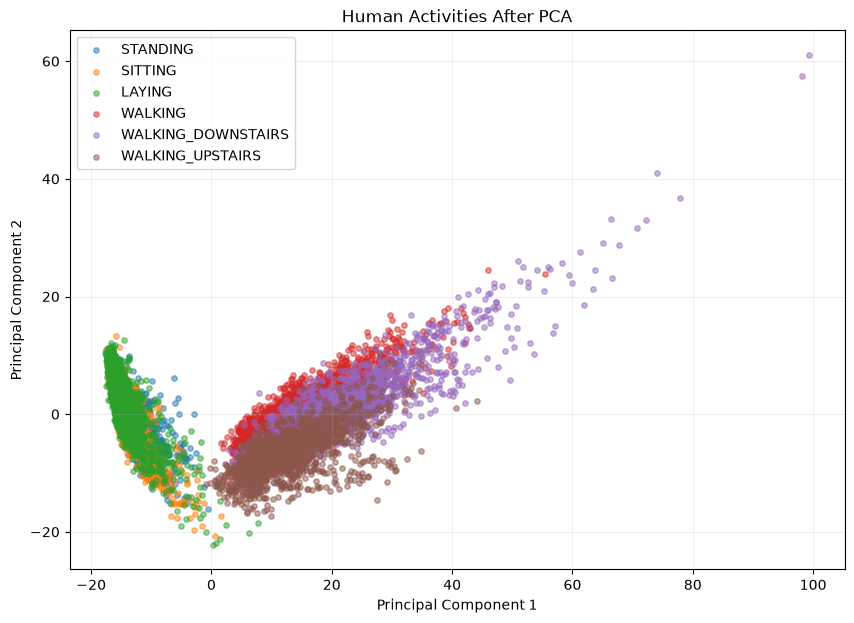

In [50]:
plt.figure(figsize=(10, 7))

for activity in y.unique():
    mask = y == activity

    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        label=activity,
        alpha=0.5,
        s=15
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Human Activities After PCA")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-radius:14px; padding:22px; margin:18px 0;">

<h3 style="color:#4F46E5; margin-top:0;">What Can I See?</h3>

<div style="display:flex; gap:14px; flex-wrap:wrap;">

<div style="flex:1; min-width:200px; background:#EEF2FF; border-radius:10px; padding:16px;">
<b style="color:#4338CA;">Static Activities</b>
<p style="color:#374151; margin-bottom:0;">
Standing, sitting, and laying appear mainly on the left side of the plot.
</p>
</div>

<div style="flex:1; min-width:200px; background:#F5F3FF; border-radius:10px; padding:16px;">
<b style="color:#7C3AED;">Moving Activities</b>
<p style="color:#374151; margin-bottom:0;">
Walking activities appear mainly on the right side, where PC1 values are more positive.
</p>
</div>

<div style="flex:1; min-width:200px; background:#FFF7ED; border-radius:10px; padding:16px;">
<b style="color:#B45309;">Some Overlap</b>
<p style="color:#374151; margin-bottom:0;">
Similar activities overlap because two components cannot show all the information in the original 561 features.
</p>
</div>

</div>
</div>

### Observation

The clearest pattern is the separation between static and moving activities.

Standing, sitting, and laying are mostly located on the left side of the plot, while walking, walking upstairs, and walking downstairs appear mainly on the right.

However, there is still overlap between activities from the same group. For example, the three walking activities have similar sensor patterns, so they are not completely separated using only two components.

A few walking-downstairs points appear far from the main group. These may represent unusually strong movements or sensor readings, but they cannot be treated as data errors without further investigation.

<div style="background:linear-gradient(135deg,#4F46E5,#635BEE); color:white; border-radius:14px; padding:20px 24px; margin:18px 0;">

<div style="font-size:14px; opacity:0.85;">MAIN INSIGHT</div>

<h3 style="color:white; margin:7px 0;">
PC1 mainly separates static activities from moving activities.
</h3>

<p style="margin:0; line-height:1.7;">
The 2D view reveals the main structure of the dataset, but it does not preserve enough information to perfectly separate all six activities.
</p>

</div>

<div style="background:linear-gradient(135deg,#4F46E5,#635BEE); border-radius:16px; padding:24px 28px; margin:24px 0; color:white;">

<h2 style="margin:0 0 8px 0; color:white;">What Did PCA Preserve and Cost?</h2>

<p style="margin:0; opacity:0.95;">
Summarize the benefit and trade-off of dimensionality reduction.
</p>

</div>

<div style="display:flex; gap:16px; flex-wrap:wrap; margin:18px 0;">

<div style="flex:1; min-width:260px; background:#ECFDF5; border-left:5px solid #10B981; border-radius:12px; padding:18px;">

<h3 style="color:#047857; margin-top:0;">What We Preserved</h3>

<ul style="color:#374151; line-height:1.8; margin-bottom:0;">
<li>95.05% of the total variance using 104 components.</li>
<li>All 10,299 observations.</li>
<li>The main difference between static and moving activities.</li>
</ul>

</div>

<div style="flex:1; min-width:260px; background:#FFF7ED; border-left:5px solid #F59E0B; border-radius:12px; padding:18px;">

<h3 style="color:#B45309; margin-top:0;">What It Cost</h3>

<ul style="color:#374151; line-height:1.8; margin-bottom:0;">
<li>About 4.95% of the total variance was removed.</li>
<li>The components no longer have simple sensor-feature names.</li>
<li>The 2D view keeps only about 56.98% of the variance.</li>
</ul>

</div>

</div>

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-left:6px solid #4F46E5; border-radius:14px; padding:22px; margin:18px 0;">

<h2 style="color:#4F46E5; margin-top:0;">PCA Results at a Glance</h2>

<p style="color:#1F2937; line-height:1.7; margin-bottom:0;">
The table below compares the original dataset with the two reduced versions created during this lab.
</p>

</div>

In [51]:
pca_summary = pd.DataFrame({
    "Version": ["Original Data", "PCA for 95%", "PCA for 2D"],
    "Dimensions": [561, 104, 2],
    "Variance Retained": [
        "100%",
        f"{pca_95.explained_variance_ratio_.sum() * 100:.2f}%",
        f"{variance_2d * 100:.2f}%"
    ],
    "Purpose": [
        "Complete sensor data",
        "Reduced dataset",
        "Visualization only"
    ]
})

pca_summary

,Version,Dimensions,Variance Retained,Purpose
0,Original Data,561,100%,Complete sensor data
1,PCA for 95%,104,95.05%,Reduced dataset
2,PCA for 2D,2,56.98%,Visualization only


### Observation

The 104-component version gives the best balance between reducing dimensions and preserving information.

The 2D version is easier to visualize, but it keeps only 56.98% of the variance. For this reason, I would use the 104-component data for further analysis and keep the 2D version only for visualization.

<div style="background:linear-gradient(135deg,#4F46E5,#635BEE); border-radius:16px; padding:26px 30px; margin:24px 0; color:white;">

<h2 style="color:white; margin-top:0;">Final Conclusion</h2>

<p style="line-height:1.8;">
This dataset originally contained 561 sensor features, which made it difficult to explore and visualize.
After scaling the features, PCA showed that only 104 components were needed to preserve 95.05% of the total variance.
</p>

<p style="line-height:1.8;">
The two-dimensional view also revealed a general separation between static and moving activities, although similar activities still overlapped.
</p>

<p style="line-height:1.8; margin-bottom:0;">
Overall, PCA successfully reduced the complexity of the dataset, but the new components are less interpretable than the original sensor features.
</p>

</div>

<div style="background:#F8FAFC; border:1px solid #DDE1EA; border-radius:14px; padding:22px; margin:18px 0;">

<h3 style="color:#4F46E5; margin-top:0;">Key Takeaways</h3>

<ul style="color:#374151; line-height:1.9; margin-bottom:0;">
<li>PCA was applied after StandardScaler because PCA depends on variance.</li>
<li>The dataset was reduced from 561 features to 104 components.</li>
<li>The reduced data preserved 95.05% of the original variance.</li>
<li>Only two components were used for visualization.</li>
<li>The 2D plot preserved 56.98% of the variance.</li>
<li>PCA reduced complexity, but the components lost the direct meaning of the original features.</li>
</ul>

</div>